In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import gapMetrics
import bacteriaSys
import controllers

In [3]:
#call functions
params = bacteriaSys.default_params_2()
Ad1, Bd1 = bacteriaSys.discretize_AB(0.7, 0.03, 1.0)
print("Discretized A matrix:\n", Ad1)
print("Discretized B matrix:\n", Bd1)
Ad2, Bd2 = bacteriaSys.discretize_AB(0.6, 0.04, 1.0)
C = np.array([[0, 1]])
D = np.array([[0]])
num1, den1 = gapMetrics.ss_to_tf_discrete(Ad1, Bd1, C, D)
num2, den2 = gapMetrics.ss_to_tf_discrete(Ad2, Bd2, C, D)
v_gap = gapMetrics.vgap_metric(num1, den1, num2, den2)
print("v-gap between the two systems:", v_gap)
#For proportional controller with gain K
K = 1.0
num3 = np.empty((1, 1), dtype=object)
den3 = np.empty((1, 1), dtype=object)
num3[0, 0] = np.array([K])
den3[0, 0] = np.array([1.0])

bpc, _, _ = gapMetrics.vgap_bpc(num1, den1, num3, den3)
print("bpc:", bpc)

#simulate system to get data
u = gapMetrics.persistently_exciting_input(50)
x,y = gapMetrics.simulate_system(Ad1, Bd1, C, D, u)
# print("x", u.shape)

A_hat, B_hat = gapMetrics.estimate_AB(u.T, x.T)
print("Estimated A matrix:\n", A_hat)
print("Estimated B matrix:\n", B_hat)

Discretized A matrix:
 [[0.4965853  0.        ]
 [0.70725407 0.97044553]]
Discretized B matrix:
 [[0.71916385]
 [0.39699258]]
v-gap between the two systems: (0.04390122146430629, np.float64(0.04390122146430629))
bpc: 0.692104946462384
Estimated A matrix:
 [[ 4.96585304e-01 -4.84301531e-17]
 [ 7.07254074e-01  9.70445534e-01]]
Estimated B matrix:
 [[0.71916385]
 [0.39699258]]


In [4]:
#Function from data to bpc
# Assumed P controller with gain K
def data_to_bpc(u,x,K):
    A_hat, B_hat = gapMetrics.estimate_AB(u.T, x.T)
    C = np.array([[0, 1]])
    D = np.array([[0]])
    num, den = gapMetrics.ss_to_tf_discrete(A_hat, B_hat, C, D)
    Abk = A_hat - B_hat * K
    num3, den3 = gapMetrics.ss_to_tf_discrete(Abk, B_hat, C, D)
    bpc, _, _ = gapMetrics.vgap_bpc(num, den, num3, den3)
    return bpc

#
def data_to_vgap(u1, x1, u2, x2):
    A_hat1, B_hat1 = gapMetrics.estimate_AB(u1.T, x1.T)
    A_hat2, B_hat2 = gapMetrics.estimate_AB(u2.T, x2.T)
    C = np.array([[0, 1]])
    D = np.array([[0]])
    num1, den1 = gapMetrics.ss_to_tf_discrete(A_hat1, B_hat1, C, D)
    num2, den2 = gapMetrics.ss_to_tf_discrete(A_hat2, B_hat2, C, D)
    v_gap, _ = gapMetrics.vgap_metric(num1, den1, num2, den2)
    return v_gap

In [5]:
#LQR wrapper

def LQR_wrapper(u,x):
    Q = np.eye(2)
    R = np.eye(1)*0.1 #TODO: can adapt to n change
    T_d = 20  #data length for LQR
    U0 = u[0:T_d].T        # shape (m, T)  == U_{0,1,T}
    X0 = x[0:T_d, :].T # shape (n, T)  == X_{0,T}
    X1 = x[1:T_d+1, :].T # shape (n, T)  == X_{1,T}
    K_control = controllers.DataLQRcontroller(U0, X0, X1, Q, R)
    return K_control

In [ ]:
#generate some random systems
num_systems = 25
T = 50 #number of data points each system
L = 15  #Hankel matrix depth
C = np.array([[0.5, 1]])
D = np.array([[0]])
u = gapMetrics.persistently_exciting_input(T, m=1, std=1.0)
stored_hankels = []
H_u = gapMetrics.hankel_matrix(u, L)
#store x for LQR related
stored_x = []
#store A and B for checking
stored_A = []
stored_B = []
for i in range(num_systems):
    random_params_1 = random.random()
    random_params_2 = random.random()
    # print("Generating system", i+1, "with params:", random_params_1, random_params_2)
    A, B =bacteriaSys.discretize_AB(random_params_1, random_params_2, 1.0)
    # print("A matrix:\n", A)
    # print("B matrix:\n", B)
    x, y = gapMetrics.simulate_system(A, B, C, D, u)
    H_y = gapMetrics.hankel_matrix(y, L)
    H = np.vstack([H_u, H_y])
    stored_x.append(x)
    stored_hankels.append(H)
    stored_A.append(A)
    stored_B.append(B)

In [7]:
#compute L gaps
# m = 1      # number of inputs
# n = 2      # state dimension
# D = np.zeros((num_systems, num_systems))
# for i in range(num_systems):
#     for j in range(i+1, num_systems):
#         gij, *_ = gapMetrics.Lgap_metric(stored_hankels[i], stored_hankels[j], m, n, L, use_alt_formula=False)
#         D[i, j] = gij
#         D[j, i] = gij

#compute v-gaps from data
D = np.zeros((num_systems, num_systems))
for i in range(num_systems):
    for j in range(i+1, num_systems):
        vij = data_to_vgap(u, stored_x[i], u, stored_x[j])
        D[i, j] = vij
        D[j, i] = vij
        print("v-gap between system", i, "and", j, ":", vij)
#problem: takes too long

print("D:", D)


v-gap between system 0 and 1 : 0.11849647840632456
v-gap between system 0 and 2 : 0.2949763403646958
v-gap between system 0 and 3 : 0.32623252071240716
v-gap between system 0 and 4 : 0.24499581957460892
v-gap between system 0 and 5 : 0.2681025009022204
v-gap between system 0 and 6 : 0.21299710013335194
v-gap between system 0 and 7 : 0.07186537480009378
v-gap between system 0 and 8 : 0.34653492056104723
v-gap between system 0 and 9 : 0.02760361361751118
v-gap between system 0 and 10 : 0.2905029644079974
v-gap between system 0 and 11 : 0.11168431831398579
v-gap between system 0 and 12 : 0.36382499188107764
v-gap between system 0 and 13 : 0.2533927760625649
v-gap between system 0 and 14 : 0.11088786605796397
v-gap between system 0 and 15 : 0.21062546774838842
v-gap between system 0 and 16 : 0.14238139867331165
v-gap between system 0 and 17 : 0.28753556060195495
v-gap between system 0 and 18 : 0.3314385594583421
v-gap between system 0 and 19 : 0.09382704088335093
v-gap between system 0 and

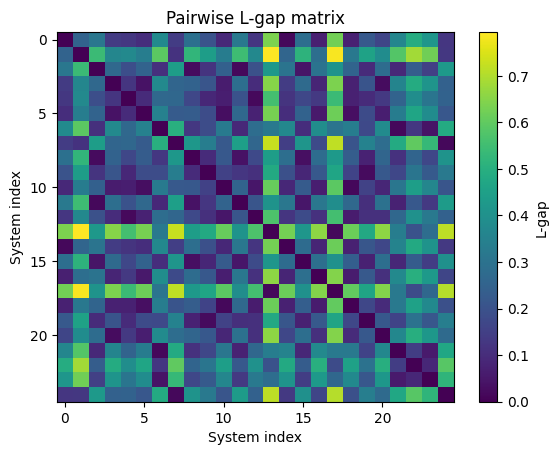

In [ ]:

plt.figure()
plt.imshow(D, interpolation="nearest", aspect="auto")
plt.colorbar(label="v-gap")
plt.title("Pairwise v-gap matrix")
plt.xlabel("System index")
plt.ylabel("System index")
plt.show()

In [26]:
print("D:", D[13,1])

D: 0.7937965158645223


In [20]:
def leader_groups(D, threshold):
    """
    Star clustering: each group has a leader c, and all members i satisfy D[i,c] <= threshold.
    Greedy: choose leader that covers the most uncovered nodes.
    Returns list of dicts: [{"leader": c, "members": [...]}]
    """
    N = D.shape[0]
    uncovered = set(range(N))
    groups = []

    # Precompute who is within threshold of whom (including self)
    within = [set(np.where(D[i] <= threshold)[0].tolist()) for i in range(N)]

    while uncovered:
        # choose leader that covers most uncovered nodes
        best_leader = None
        best_cover = set()
        for i in uncovered:
            cover = within[i] & uncovered
            if len(cover) > len(best_cover):
                best_cover = cover
                best_leader = i

        members = sorted(best_cover)
        groups.append({"leader": int(best_leader), "members": [int(x) for x in members]})

        # mark them covered
        for x in best_cover:
            uncovered.remove(x)

    return groups


In [19]:
#better method (TODO: improve timing)
def medoid(D, indices):
    """
    D: (N,N) distance matrix
    indices: iterable of system indices (e.g. uncovered systems)

    Returns:
        leader index (int)
    """
    U = np.array(sorted(indices))  # sorted for determinism
    subD = D[np.ix_(U, U)]          # distances restricted to U × U

    # average distance from each candidate to others in U
    mean_dist = subD.mean(axis=1)
    # TODO: fix number of group members?

    # index of minimum mean distance
    leader = int(U[np.argmin(mean_dist)])
    return leader

def leader_groups2(D):
    N = D.shape[0]
    uncovered = set(range(N))
    groups = []

    while uncovered:
        # 1) pick central leader
        leader = medoid(D, uncovered)
        U = np.array(sorted(uncovered))
        dists = D[leader, U]
        # 2) find leader-specific threshold
        K = LQR_wrapper(u, stored_x[leader])
        print("K for leader", leader, ":", K)
        # print("stored_x[leader]:", u.shape)
        threshold = data_to_bpc(u, stored_x[leader], K)
        print("Threshold for leader", leader, ":", threshold)
        # 3) assign members
        members = U[dists <= threshold].tolist()
        members = [int(x) for x in members]

        groups.append({
            "leader": leader,
            "eps": threshold,
            "members": members
        })

        # 4) remove covered
        for x in members:
            uncovered.remove(x)

    return groups


In [15]:
#Clustering with specified m leaders
def pick_leaders(D, m):
    mean_dist = D.mean(axis=1)
    leaders = np.argsort(mean_dist)[:m].astype(int).tolist()  # pick m with smallest mean distance
    thresholds = []
    for leader in leaders:    
        K = LQR_wrapper(u, stored_x[leader])
        print("K for leader", leader, ":", K)
        # print("stored_x[leader]:", u.shape)
        threshold = data_to_bpc(u, stored_x[leader], K)
        thresholds.append(threshold)
    return leaders, thresholds

def assign_to(D, leaders, thresholds):
    N = D.shape[0]
    leaders = np.asarray(leaders, dtype=int)
    thresholds = np.asarray(thresholds, dtype=float)
    dist = D[:, leaders]  # shape (N, m)
    feasible = dist <= thresholds[None, :]
    leader_of = -np.ones(N, dtype=int)
    dist_to_leader = np.full(N, np.inf, dtype=float)
    for i in range(N):
        ok = np.where(feasible[i])[0]
        if ok.size == 0:
            continue  # remains unassigned
        # among feasible leaders, pick the closest
        kbest = ok[np.argmin(dist[i, ok])]
        leader_of[i] = leaders[kbest]
        dist_to_leader[i] = dist[i, kbest]

    return leader_of, dist_to_leader

def leader_groups_fixed(D, m):
    leaders, thresholds = pick_leaders(D, m)
    leader_of, dist_to_leader = assign_to(D, leaders, thresholds)
    groups = []
    for k, leader in enumerate(leaders):
        members = np.where(leader_of == leader)[0].astype(int).tolist()
        groups.append({
            "leader": int(leader),
            "eps": float(thresholds[k]),
            "members": members
        })
    return groups

In [27]:
def farthest_seeds(D, m, mode="avg"):
    """
    pick m plants far apart.
    mode:
      - "avg": next seed maximizes average distance to existing plants
      - "min": next seed maximizes minimum distance to existing plants
    """
    N = D.shape[0]
    if m > N:
        raise ValueError("m cannot exceed number of plants")

    # First two: farthest pair
    i0, j0 = np.unravel_index(np.argmax(D), D.shape)
    seeds = [int(i0), int(j0)]

    while len(seeds) < m:
        candidates = [i for i in range(N) if i not in seeds]
        if mode == "avg":
            scores = [float(np.mean(D[i, seeds])) for i in candidates]
        elif mode == "min":
            scores = [float(np.min(D[i, seeds])) for i in candidates]
        else:
            raise ValueError("mode must be 'avg' or 'min'")
        seeds.append(int(candidates[int(np.argmax(scores))]))

    return seeds


def assign_by_smallest_group_average(D, seeds, order="hard_first"):
    """
    Incrementally assign remaining points.
    Each point is assigned to the group that yields smallest average distance to current members.
    """
    N = D.shape[0]
    groups = {s: [s] for s in seeds}  # key=seed id, value=list of members

    remaining = [i for i in range(N) if i not in seeds]

    if order == "hard_first":
        # points farthest from the seed set get assigned first
        seed_arr = np.array(seeds, dtype=int)
        d_to_seedset = np.min(D[:, seed_arr], axis=1)
        remaining.sort(key=lambda i: -d_to_seedset[i])
    elif order == "index":
        pass
    else:
        raise ValueError("order must be 'hard_first' or 'index'")

    for i in remaining:
        best_seed = None
        best_cost = np.inf
        for s, members in groups.items():
            cost = float(np.mean(D[i, members]))  # average distance to group members
            if cost < best_cost:
                best_cost = cost
                best_seed = s
        groups[best_seed].append(int(i))

    return groups  # dict(seed -> members)


def medoid_of_group(D, members):
    """
    Helper: choose leader as medoid (min sum distance within group).
    """
    members = np.array(members, dtype=int)
    subD = D[np.ix_(members, members)]
    k = int(np.argmin(subD.sum(axis=1)))
    return int(members[k])


def build_groups_and_check_thresholds(D, groups_dict):
    """
    Find leader, compute threshold, verify all within threshold.
    threshold_fn(members, leader) -> eps
      If None, eps is treated as +inf (no check).
    try_repair_leader:
      If True, and chosen medoid fails, try any member as leader that passes the threshold.
    """
    out = []
    for seed, members in groups_dict.items():
        leader = medoid_of_group(D, members)
         
        K = LQR_wrapper(u, stored_x[leader])
        print("K for leader", leader, ":", K)
        # print("stored_x[leader]:", u.shape)
        eps = data_to_bpc(u, stored_x[leader], K)
        dists = D[np.array(members, dtype=int), leader]

        ok = np.all(dists <= eps + 1e-12)

        # if (not ok) and try_repair_leader and threshold_fn is not None:
        #     # try to find any member that makes the group feasible
        #     repaired = False
        #     for cand in members:
        #         eps_c = float(threshold_fn(members, cand))
        #         if np.all(D[np.array(members, dtype=int), cand] <= eps_c + 1e-12):
        #             leader = int(cand)
        #             eps = eps_c
        #             repaired = True
        #             break
        #     ok = repaired

        if not ok:
            # provide a helpful error message
            worst = float(np.max(dists))
            raise ValueError(
                f"Threshold violation for group seeded by {seed}: "
                f"leader={leader}, eps={eps:.4g}, worst_dist={worst:.4g}, size={len(members)}"
            )

        out.append({"seed": int(seed), "leader": int(leader), "eps": float(eps), "members": [int(x) for x in members]})

    return out


# ----- Full pipeline -----

def cluster_farthest_assign_medoid_threshold(D, m, seed_mode="avg",
                                            assign_order="hard_first"):
    """
    Implements 3 steps:
      1) farthest m plants
      2) one-by-one assignment to smallest average distance group
      3) leader = medoid, check all within leader threshold
    """
    seeds = farthest_seeds(D, m, mode=seed_mode)
    groups_dict = assign_by_smallest_group_average(D, seeds, order=assign_order)
    groups = build_groups_and_check_thresholds(D, groups_dict)
    return groups


In [ ]:
eps = 0.2
# groups = leader_groups(D, eps)
# groups = leader_groups2(D)
# groups = leader_groups_fixed(D, 3)
groups = cluster_farthest_assign_medoid_threshold(D, 3)
for g in groups:
    print("leader:", g["leader"], "size:", len(g["members"]), "members:", g["members"])
# print("groups:", groups)
# groups = [{"leader": c, "members": [...]}, ...]

N = D.shape[0]
leader_of = np.full(N, -1, dtype=int)
dist_to_leader = np.zeros(N)

for g in groups:
    leader = g["leader"]
    for i in g["members"]:
        leader_of[i] = leader
        dist_to_leader[i] = D[leader, i]




K for leader 23 : [[0.80611675 0.17183384]]
K for leader 24 : [[1.1884255  0.54411926]]
K for leader 9 : [[0.9855104  0.16444363]]
K for leader 21 : [[1.12512898 0.59071697]]
K for leader 5 : [[0.79708791 0.43923041]]
leader: 23 size: 2 members: [23, 3]
leader: 24 size: 2 members: [24, 8]
leader: 9 size: 9 members: [0, 16, 1, 11, 14, 19, 22, 7, 9]
leader: 21 size: 4 members: [12, 6, 4, 21]
leader: 5 size: 8 members: [18, 20, 15, 13, 5, 17, 10, 2]


C:\Users\Z PL\AppData\Local\Temp\ipykernel_44624\2037446303.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


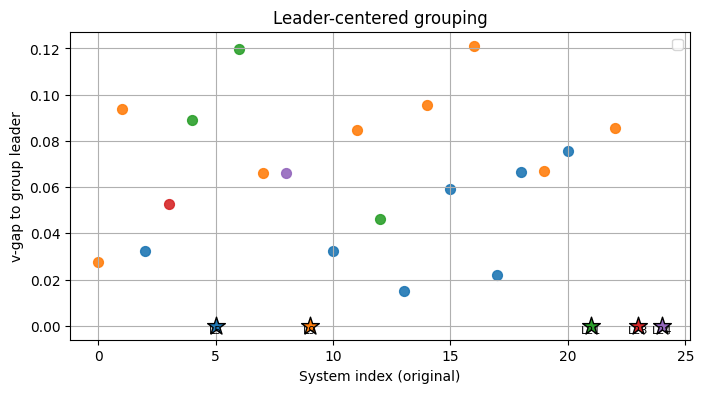

In [33]:
plt.figure(figsize=(8, 4))

unique_leaders = sorted(set(leader_of))
colors = plt.cm.tab10(range(len(unique_leaders)))
leader_color = {l: colors[k] for k, l in enumerate(unique_leaders)}

for i in range(N):
    l = leader_of[i]
    if i == l:
        # leader: star marker
        plt.scatter(
            i,
            dist_to_leader[i],
            marker="*",
            s=180,
            color=leader_color[l],
            edgecolor="k",
            zorder=3,
        )
        plt.text(i, 0, f"L{l}", ha="center", va="top", fontsize=8)
    else:
        plt.scatter(
            i,
            dist_to_leader[i],
            color=leader_color[l],
            s=50,
            alpha=0.9,
        )

# plt.axhline(eps, linestyle="--", color="gray", label="threshold")
plt.xlabel("System index (original)")
plt.ylabel("v-gap to group leader")
plt.title("Leader-centered grouping")
plt.grid(True)
plt.legend()
plt.show()


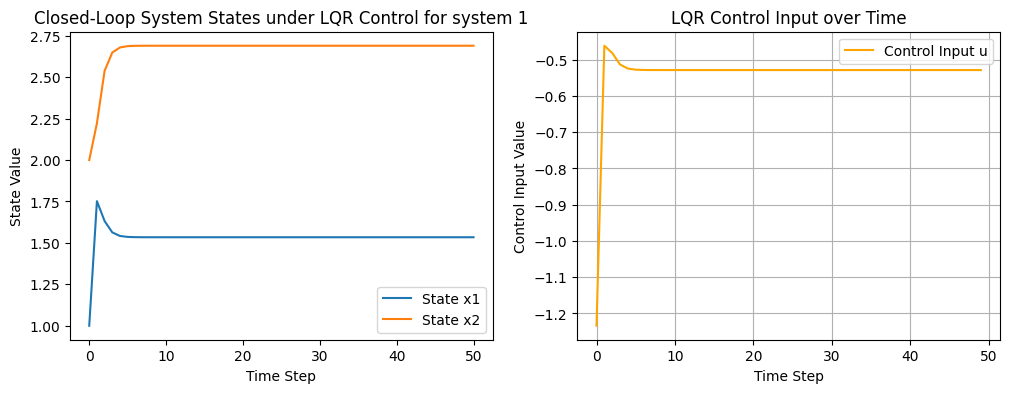

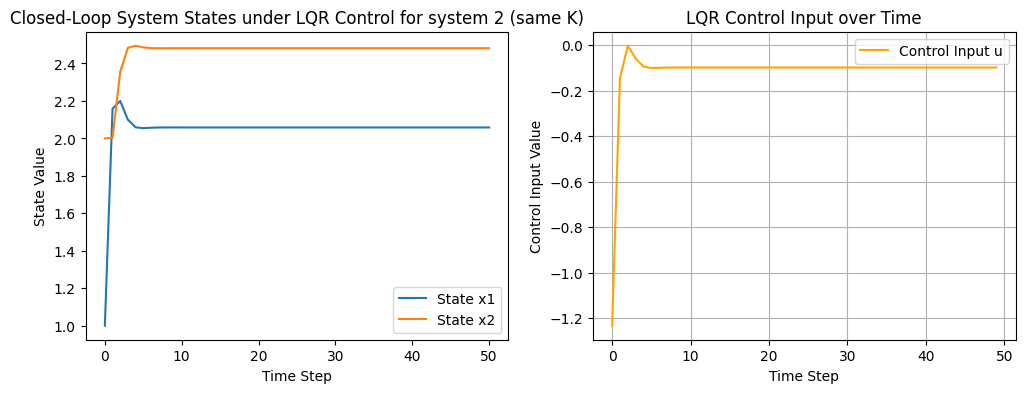

In [36]:
#proof of controllability

#test whether the same controller can be used for 2 systems
#LQR controller
Q = np.eye(2)
# Q[1,1] = 0 #get rid of x2 penalty
R = np.eye(1)*0.1
T_d = 20  #data length for LQR

U0 = u[0:T_d].T        # shape (m, T)  == U_{0,1,T}
X0 = stored_x[1][0:T_d, :].T # shape (n, T)  == X_{0,T}
X1 = stored_x[1][1:T_d+1, :].T # shape (n, T)  == X_{1,T}

# simulate closed loop system. Assumed using system 1 where A is a 2x2 matrix
N = 50 #number of control steps
x0 = np.array([[1],[2]]) #initial state
x_cl = np.zeros((N+1, x0.shape[0], x0.shape[1]))
x_cl[0, :, :] = x0 #initial state
xf = np.array([[2],[3]]) #desired state
u_cl = np.zeros((N, R.shape[0], 1))
K_control = controllers.DataLQRcontroller(U0, X0, X1, Q, R)
# K_control = np.array([[2, 1]])  #test with wrong controller
for k in range(N):
    u_control = -K_control @ (x_cl[k] - xf)
    x_cl[k+1] = stored_A[1] @ x_cl[k] + stored_B[1] @ u_control
    u_cl[k] = u_control

# Plot results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_cl[:,0,0], label='State x1')
plt.plot(x_cl[:,1,0], label='State x2')
plt.title('Closed-Loop System States under LQR Control for system 1')
plt.xlabel('Time Step')
plt.ylabel('State Value')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(N), -u_cl[:,0,0], label='Control Input u', color='orange')
plt.title('LQR Control Input over Time')
plt.xlabel('Time Step')
plt.ylabel('Control Input Value')
plt.legend()
plt.grid()
plt.show()

#use same controller on system 2
for k in range(N):
    u_control = -K_control @ (x_cl[k] - xf)
    x_cl[k+1] = stored_A[7] @ x_cl[k] + stored_B[7] @ u_control
    u_cl[k] = u_control

# Plot results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_cl[:,0,0], label='State x1')
plt.plot(x_cl[:,1,0], label='State x2')
plt.title('Closed-Loop System States under LQR Control for system 2 (same K)')
plt.xlabel('Time Step')
plt.ylabel('State Value')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(N), -u_cl[:,0,0], label='Control Input u', color='orange')
plt.title('LQR Control Input over Time')
plt.xlabel('Time Step')
plt.ylabel('Control Input Value')
plt.legend()
plt.grid()
plt.show()

#TODO: dot z = x; check data based I controller (for 4yp)
#TODO: specify multiple groups

In [ ]:
leaders = np.argsort(mean_dist)[:m].astype(int).tolist()

